In [29]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
def load_and_filter(path, year_min, year_max, year_col="Year"):
    df = pd.read_csv(path)
    return df[(df[year_col] >= year_min) & (df[year_col] <= year_max)].reset_index(drop=True)

meta_cols = ["Country Name", "Country Code", "Series Name", "Series Code"]

In [16]:
df_ukraine_asylum = pd.read_csv("data/raw/ukraine/asylum_applications_ukraine.csv")
df_ukraine_asylum = df_ukraine_asylum[(df_ukraine_asylum["Year"] >= 2012) & (df_ukraine_asylum["Year"] <= 2025)].reset_index(drop=True)

df_ukraine_refugees_origin = pd.read_csv("data/raw/ukraine/refugees_by_origin_ukraine.csv")
df_ukraine_refugees_origin = df_ukraine_refugees_origin[(df_ukraine_refugees_origin["Year"] >= 2012) & (df_ukraine_refugees_origin["Year"] <= 2025)].reset_index(drop=True)

df_ukraine_refugees_returnees = pd.read_csv("data/raw/ukraine/refugees_returnees_ukraine.csv")
df_ukraine_refugees_returnees = df_ukraine_refugees_returnees[(df_ukraine_refugees_returnees["Year"] >= 2012) & (df_ukraine_refugees_returnees["Year"] <= 2025)].reset_index(drop=True)

df_ukraine_idp = pd.read_csv("data/raw/ukraine/internally_displaced_people_ukraine.csv")
df_ukraine_idp = df_ukraine_idp[(df_ukraine_idp["Year"] >= 2012) & (df_ukraine_idp["Year"] <= 2025)].reset_index(drop=True)

df_ukraine_idp_returnees = pd.read_csv("data/raw/ukraine/internally_displaced_people_returnees_ukraine.csv")
df_ukraine_idp_returnees = df_ukraine_idp_returnees[(df_ukraine_idp_returnees["Year"] >= 2012) & (df_ukraine_idp_returnees["Year"] <= 2025)].reset_index(drop=True)

df_ukraine_wb_wide = pd.read_csv("data/raw/ukraine/world_bank_group_ukraine.csv")
year_cols_ukraine = [c for c in df_ukraine_wb_wide.columns if any(str(y) in c for y in range(2012, 2026))]
df_ukraine_wb_wide = df_ukraine_wb_wide[meta_cols + year_cols_ukraine]

In [17]:
df_iraq_asylum = pd.read_csv("data/raw/irak/asylum_applications_irak.csv")
df_iraq_asylum = df_iraq_asylum[(df_iraq_asylum["Year"] >= 2001) & (df_iraq_asylum["Year"] <= 2013)].reset_index(drop=True)

df_iraq_refugees_origin = pd.read_csv("data/raw/irak/refugees_by_origin_irak.csv")
df_iraq_refugees_origin = df_iraq_refugees_origin[(df_iraq_refugees_origin["Year"] >= 2001) & (df_iraq_refugees_origin["Year"] <= 2013)].reset_index(drop=True)

df_iraq_refugees_returnees = pd.read_csv("data/raw/irak/refugees_returnees_irak.csv")
df_iraq_refugees_returnees = df_iraq_refugees_returnees[(df_iraq_refugees_returnees["Year"] >= 2001) & (df_iraq_refugees_returnees["Year"] <= 2013)].reset_index(drop=True)

df_iraq_idp = pd.read_csv("data/raw/irak/internally_displaced_people_irak.csv")
df_iraq_idp = df_iraq_idp[(df_iraq_idp["Year"] >= 2001) & (df_iraq_idp["Year"] <= 2013)].reset_index(drop=True)

df_iraq_idp_returnees = pd.read_csv("data/raw/irak/internally_displaced_people_returnees_irak.csv")
df_iraq_idp_returnees = df_iraq_idp_returnees[(df_iraq_idp_returnees["Year"] >= 2001) & (df_iraq_idp_returnees["Year"] <= 2013)].reset_index(drop=True)

df_iraq_wb_wide = pd.read_csv("data/raw/irak/world_bank_group_irak.csv")
year_cols_iraq = [c for c in df_iraq_wb_wide.columns if any(str(y) in c for y in range(2001, 2014))]
df_iraq_wb_wide = df_iraq_wb_wide[meta_cols + year_cols_iraq]

In [18]:
df_bosnia_refugees_origin = pd.read_csv("data/raw/bosnie/refugees_by_origin_bosnia.csv")
df_bosnia_refugees_origin = df_bosnia_refugees_origin[(df_bosnia_refugees_origin["Year"] >= 1991) & (df_bosnia_refugees_origin["Year"] <= 1997)].reset_index(drop=True)

df_bosnia_refugees_returnees = pd.read_csv("data/raw/bosnie/refugees_returnees_bosnia.csv")
df_bosnia_refugees_returnees = df_bosnia_refugees_returnees[(df_bosnia_refugees_returnees["Year"] >= 1991) & (df_bosnia_refugees_returnees["Year"] <= 1997)].reset_index(drop=True)

df_bosnia_idp_returnees = pd.read_csv("data/raw/bosnie/internally_displaced_people_returnees_bosnia.csv")
df_bosnia_idp_returnees = df_bosnia_idp_returnees[(df_bosnia_idp_returnees["Year"] >= 1991) & (df_bosnia_idp_returnees["Year"] <= 1997)].reset_index(drop=True)

df_bosnia_wb_wide = pd.read_csv("data/raw/bosnie/world_bank_group_bosnia.csv")
year_cols_bosnia = [c for c in df_bosnia_wb_wide.columns if any(str(y) in c for y in range(1991, 1998))]
df_bosnia_wb_wide = df_bosnia_wb_wide[meta_cols + year_cols_bosnia]

In [19]:
dataframes_ukraine = {
    "asylum_applications": df_ukraine_asylum,
    "refugees_by_origin":  df_ukraine_refugees_origin,
    "refugees_returnees":  df_ukraine_refugees_returnees,
    "idp":                 df_ukraine_idp,
    "idp_returnees":       df_ukraine_idp_returnees,
    "world_bank_wide":     df_ukraine_wb_wide,
}

dataframes_iraq = {
    "asylum_applications": df_iraq_asylum,
    "refugees_by_origin":  df_iraq_refugees_origin,
    "refugees_returnees":  df_iraq_refugees_returnees,
    "idp":                 df_iraq_idp,
    "idp_returnees":       df_iraq_idp_returnees,
    "world_bank_wide":     df_iraq_wb_wide,
}

dataframes_bosnia = {
    "refugees_by_origin":  df_bosnia_refugees_origin,
    "refugees_returnees":  df_bosnia_refugees_returnees,
    "idp_returnees":       df_bosnia_idp_returnees,
    "world_bank_wide":     df_bosnia_wb_wide,
}

In [20]:
df_global_battle_death = pd.read_csv("data/raw/global/battle_death_global.csv")

df_ukraine_battle_death = df_global_battle_death[
    (df_global_battle_death["location_inc"].str.contains("Ukraine", na=False)) &
    (df_global_battle_death["year"] >= 2012) &
    (df_global_battle_death["year"] <= 2025)
].reset_index(drop=True)

df_iraq_battle_death = df_global_battle_death[
    (df_global_battle_death["location_inc"].str.contains("Iraq", na=False)) &
    (df_global_battle_death["year"] >= 2001) &
    (df_global_battle_death["year"] <= 2013)
].reset_index(drop=True)

df_bosnia_battle_death = df_global_battle_death[
    (df_global_battle_death["location_inc"].str.contains("Bosnia", na=False)) &
    (df_global_battle_death["year"] >= 1991) &
    (df_global_battle_death["year"] <= 1997)
].reset_index(drop=True)

In [21]:
df_global_dyadic = pd.read_csv("data/raw/global/dyadic_global.csv")

df_ukraine_dyadic = df_global_dyadic[
    (df_global_dyadic["location"].str.contains("Ukraine", na=False)) &
    (df_global_dyadic["year"] >= 2012) &
    (df_global_dyadic["year"] <= 2025)
].reset_index(drop=True)

df_iraq_dyadic = df_global_dyadic[
    (df_global_dyadic["location"].str.contains("Iraq", na=False)) &
    (df_global_dyadic["year"] >= 2001) &
    (df_global_dyadic["year"] <= 2013)
].reset_index(drop=True)

df_bosnia_dyadic = df_global_dyadic[
    (df_global_dyadic["location"].str.contains("Bosnia", na=False)) &
    (df_global_dyadic["year"] >= 1991) &
    (df_global_dyadic["year"] <= 1997)
].reset_index(drop=True)

In [22]:
df_global_military = pd.read_csv("data/raw/global/military_events_global.csv")

df_ukraine_military = df_global_military[
    (df_global_military["country"] == "Ukraine") &
    (df_global_military["year"] >= 2012) &
    (df_global_military["year"] <= 2025)
].reset_index(drop=True)

df_iraq_military = df_global_military[
    (df_global_military["country"] == "Iraq") &
    (df_global_military["year"] >= 2001) &
    (df_global_military["year"] <= 2013)
].reset_index(drop=True)

df_bosnia_military = df_global_military[
    (df_global_military["country"] == "Bosnia-Herzegovina") &
    (df_global_military["year"] >= 1991) &
    (df_global_military["year"] <= 1997)
].reset_index(drop=True)

In [23]:
df_global_onesided = pd.read_csv("data/raw/global/one_sided_violence_global.csv")

df_ukraine_onesided = df_global_onesided[
    (df_global_onesided["location"].str.contains("Ukraine", na=False)) &
    (df_global_onesided["year"] >= 2012) &
    (df_global_onesided["year"] <= 2025)
].reset_index(drop=True)

df_iraq_onesided = df_global_onesided[
    (df_global_onesided["location"].str.contains("Iraq", na=False)) &
    (df_global_onesided["year"] >= 2001) &
    (df_global_onesided["year"] <= 2013)
].reset_index(drop=True)

df_bosnia_onesided = df_global_onesided[
    (df_global_onesided["location"].str.contains("Bosnia", na=False)) &
    (df_global_onesided["year"] >= 1991) &
    (df_global_onesided["year"] <= 1997)
].reset_index(drop=True)

In [24]:
dataframes_ukraine.update({
    "battle_death": df_ukraine_battle_death,
    "dyadic":       df_ukraine_dyadic,
    "military":     df_ukraine_military,
    "onesided":     df_ukraine_onesided,
})

dataframes_iraq.update({
    "battle_death": df_iraq_battle_death,
    "dyadic":       df_iraq_dyadic,
    "military":     df_iraq_military,
    "onesided":     df_iraq_onesided,
})

dataframes_bosnia.update({
    "battle_death": df_bosnia_battle_death,
    "dyadic":       df_bosnia_dyadic,
    "military":     df_bosnia_military,
    "onesided":     df_bosnia_onesided,
})

In [25]:
def process_unhcr_file(path, year_min, year_max, value_col):
    """Filtre et agrège les données UNHCR par année."""
    if not os.path.exists(path):
        return pd.DataFrame(columns=['Year'])
    df = pd.read_csv(path)
    df = df[(df['Year'] >= year_min) & (df['Year'] <= year_max)]
    return df.groupby('Year')[value_col].sum().reset_index()

def process_wb_file(path, year_min, year_max):
    """Pivote les données Banque Mondiale du format Wide au format Long."""
    df = pd.read_csv(path)
    meta_cols = ["Country Name", "Country Code", "Series Name", "Series Code"]
    year_cols = [c for c in df.columns if any(str(y) in c for y in range(year_min, year_max + 1))]

    df_long = df[meta_cols + year_cols].melt(id_vars=meta_cols, value_vars=year_cols, var_name="Year_Raw", value_name="Value")
    df_long['Year'] = df_long['Year_Raw'].str.extract(r'(\d{4})').astype(int)

    df_long['Value'] = df_long['Value'].replace('..', np.nan)
    df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')

    return df_long.pivot_table(index='Year', columns='Series Name', values='Value', aggfunc='first').reset_index()


def clean_and_merge_country(country_name, kw_conflict, kw_mil, year_min, year_max, unhcr_config, global_dfs):
    base_df = pd.DataFrame({'Year': range(year_min, year_max + 1)})

    wb_suffix = "bosnia" if country_name == "bosnie" else country_name
    wb_path = f"data/raw/{country_name}/world_bank_group_{wb_suffix}.csv"
    df_wb = process_wb_file(wb_path, year_min, year_max)
    base_df = base_df.merge(df_wb, on='Year', how='left')
    wb_cols = [c for c in df_wb.columns if c != 'Year']
    base_df[wb_cols] = base_df[wb_cols].interpolate(method='linear', limit_direction='both')

    for key, (filename, val_col) in unhcr_config.items():
        path = f"data/raw/{country_name}/{filename}"
        df_unhcr = process_unhcr_file(path, year_min, year_max, val_col)
        if not df_unhcr.empty:
            df_unhcr.columns = ['Year', f"unhcr_{key}"]
            base_df = base_df.merge(df_unhcr, on='Year', how='left')
            base_df[f"unhcr_{key}"] = base_df[f"unhcr_{key}"].fillna(0)

    df_bd, df_dy, df_os, df_mil = global_dfs

    df_bd_c = df_bd[(df_bd['location_inc'].str.contains(kw_conflict, na=False)) & (df_bd['year'].between(year_min, year_max))]
    if not df_bd_c.empty:
        df_bd_agg = df_bd_c.groupby('year')[['bd_best', 'bd_low', 'bd_high']].sum().reset_index().rename(columns={'year': 'Year', 'bd_best': 'conflict_bd_best', 'bd_low': 'conflict_bd_low', 'bd_high': 'conflict_bd_high'})
        base_df = base_df.merge(df_bd_agg, on='Year', how='left')

    df_dy_c = df_dy[(df_dy['location'].str.contains(kw_conflict, na=False)) & (df_dy['year'].between(year_min, year_max))]
    if not df_dy_c.empty:
        df_dy_agg = df_dy_c.groupby('year').agg(conflict_dyad_count=('dyad_id', 'count')).reset_index().rename(columns={'year': 'Year'})
        base_df = base_df.merge(df_dy_agg, on='Year', how='left')

    df_os_c = df_os[(df_os['location'].str.contains(kw_conflict, na=False)) & (df_os['year'].between(year_min, year_max))]
    if not df_os_c.empty:
        df_os_agg = df_os_c.groupby('year')[['best_fatality_estimate', 'low_fatality_estimate', 'high_fatality_estimate']].sum().reset_index().rename(columns={'year': 'Year', 'best_fatality_estimate': 'onesided_fatality_best', 'low_fatality_estimate': 'onesided_fatality_low', 'high_fatality_estimate': 'onesided_fatality_high'})
        base_df = base_df.merge(df_os_agg, on='Year', how='left')

    df_mil_c = df_mil[(df_mil['country'] == kw_mil) & (df_mil['year'].between(year_min, year_max))]
    if not df_mil_c.empty:
        df_mil_agg = df_mil_c.groupby('year')[['sb_total_deaths_best', 'sb_intrastate_deaths_best']].sum().reset_index().rename(columns={'year': 'Year', 'sb_total_deaths_best': 'military_sb_deaths_best', 'sb_intrastate_deaths_best': 'military_intrastate_deaths_best'})
        base_df = base_df.merge(df_mil_agg, on='Year', how='left')

    conflict_cols = [c for c in base_df.columns if any(x in c for x in ['conflict', 'onesided', 'military'])]
    base_df[conflict_cols] = base_df[conflict_cols].fillna(0)

    base_df['Country'] = country_name.capitalize()
    return base_df


global_dfs = [
    pd.read_csv("data/raw/global/battle_death_global.csv"),
    pd.read_csv("data/raw/global/dyadic_global.csv"),
    pd.read_csv("data/raw/global/one_sided_violence_global.csv"),
    pd.read_csv("data/raw/global/military_events_global.csv")
]

unhcr_ukraine = {
    "asylum": ("asylum_applications_ukraine.csv", "Applied"),
    "refugees_origin": ("refugees_by_origin_ukraine.csv", "Refugees"),
    "refugees_returnees": ("refugees_returnees_ukraine.csv", "Total"),
    "idp": ("internally_displaced_people_ukraine.csv", "Total"),
    "idp_returnees": ("internally_displaced_people_returnees_ukraine.csv", "Total")
}

unhcr_iraq = {
    "asylum": ("asylum_applications_irak.csv", "Applied"),
    "refugees_origin": ("refugees_by_origin_irak.csv", "Refugees"),
    "refugees_returnees": ("refugees_returnees_irak.csv", "Total"),
    "idp": ("internally_displaced_people_irak.csv", "Total"),
    "idp_returnees": ("internally_displaced_people_returnees_irak.csv", "Total")
}

unhcr_bosnia = {
    "refugees_origin": ("refugees_by_origin_bosnia.csv", "Refugees"),
    "refugees_returnees": ("refugees_returnees_bosnia.csv", "Total"),
    "idp_returnees": ("internally_displaced_people_returnees_bosnia.csv", "Total")
}

df_ukr = clean_and_merge_country("ukraine", "Ukraine", "Ukraine", 2012, 2025, unhcr_ukraine, global_dfs)
df_irq = clean_and_merge_country("irak", "Iraq", "Iraq", 2001, 2013, unhcr_iraq, global_dfs)
df_bos = clean_and_merge_country("bosnie", "Bosnia", "Bosnia-Herzegovina", 1991, 1997, unhcr_bosnia, global_dfs)

df_panel = pd.concat([df_ukr, df_irq, df_bos], ignore_index=True)

unhcr_cols = [c for c in df_panel.columns if 'unhcr_' in c]
df_panel[unhcr_cols] = df_panel[unhcr_cols].fillna(0)

df_panel.to_csv("data/cleaned/data_cleaned_panel.csv", index=False)
print("Fichier final 'data_cleaned_panel.csv' généré avec succès !")

Fichier final 'data_cleaned_panel.csv' généré avec succès !


In [26]:
df_verif = pd.read_csv("data/cleaned/data_cleaned_panel.csv")

print("=== Structure du Dataset ===")
print(f"Lignes : {df_verif.shape[0]}, Colonnes : {df_verif.shape[1]}")

print("\n=== Nombre d'années par pays ===")
print(df_verif['Country'].value_counts())

print("\n=== Vérification des valeurs manquantes (Doit afficher 0) ===")
print(f"Total NaN : {df_verif.isna().sum().sum()}")

=== Structure du Dataset ===
Lignes : 34, Colonnes : 22

=== Nombre d'années par pays ===
Country
Ukraine    14
Irak       13
Bosnie      7
Name: count, dtype: int64

=== Vérification des valeurs manquantes (Doit afficher 0) ===
Total NaN : 14


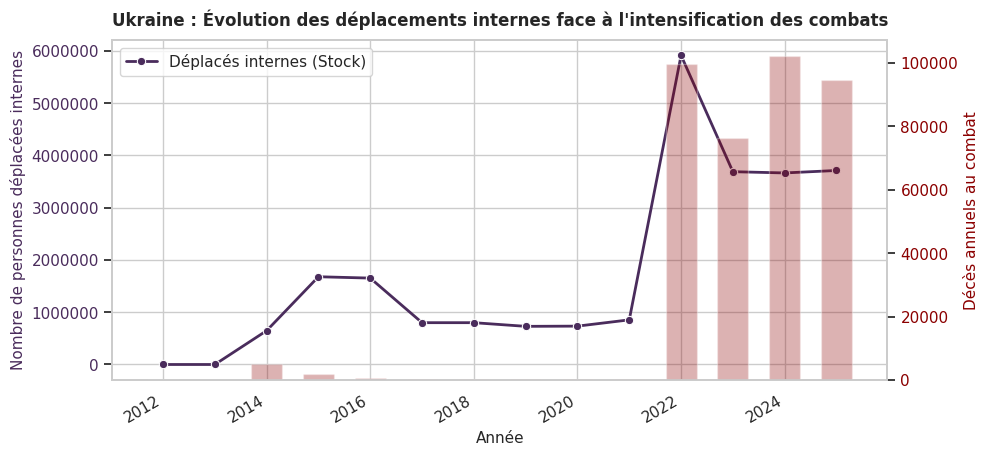

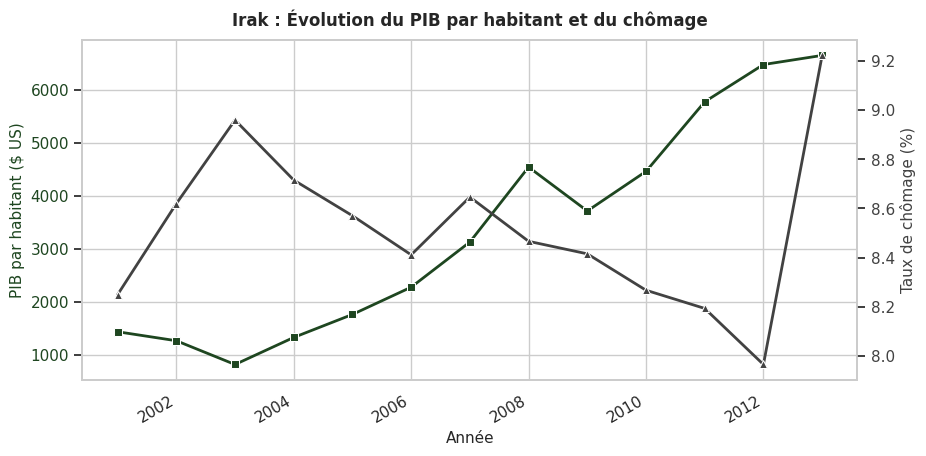

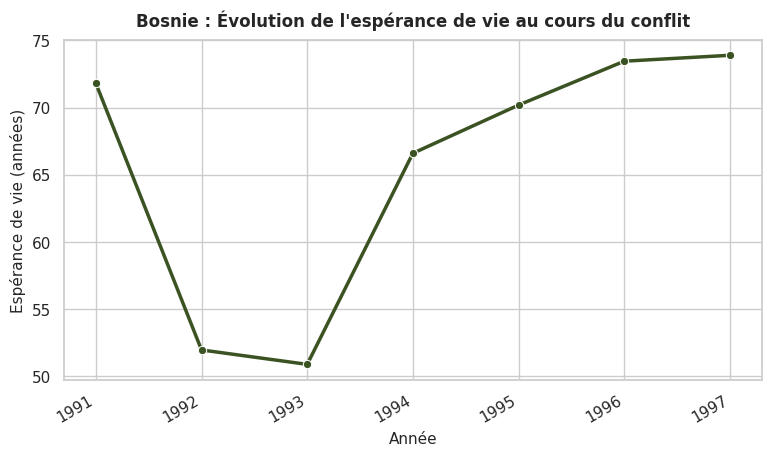

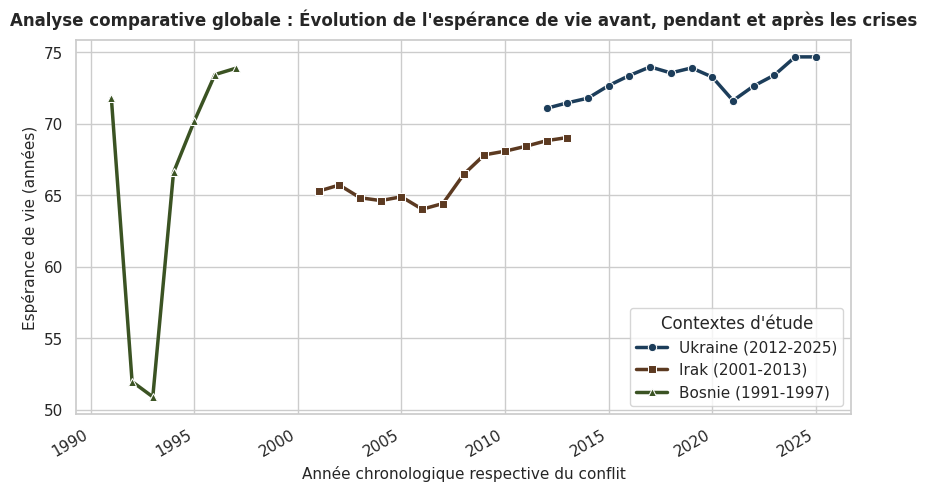

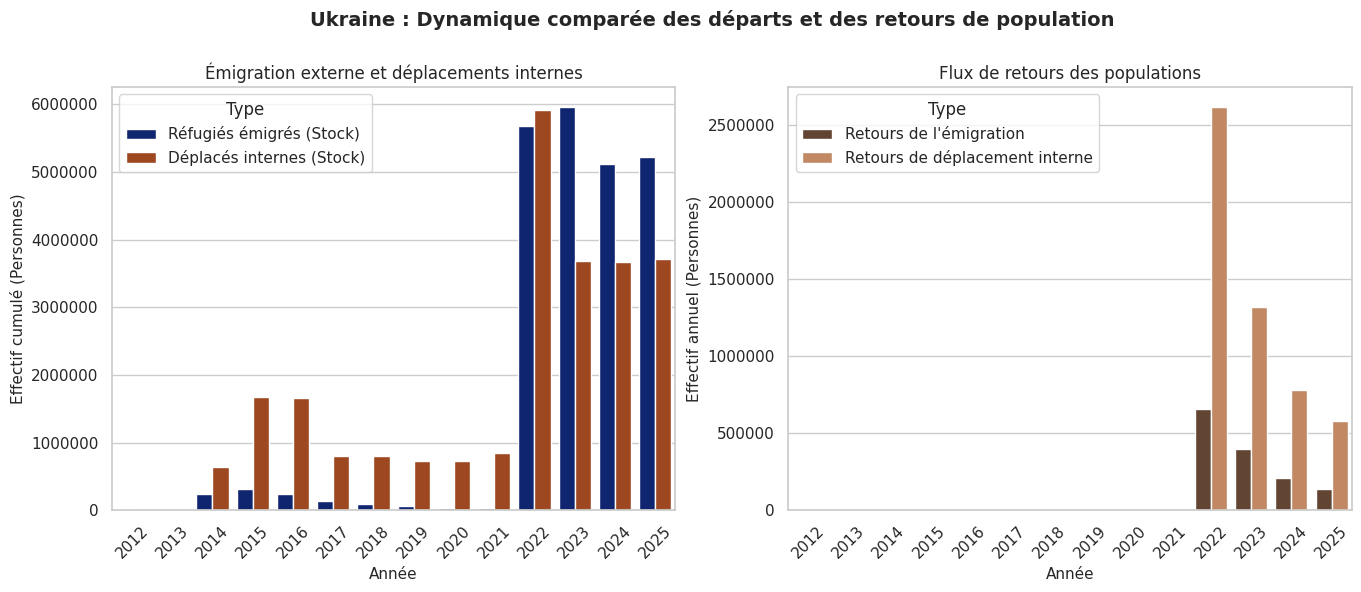

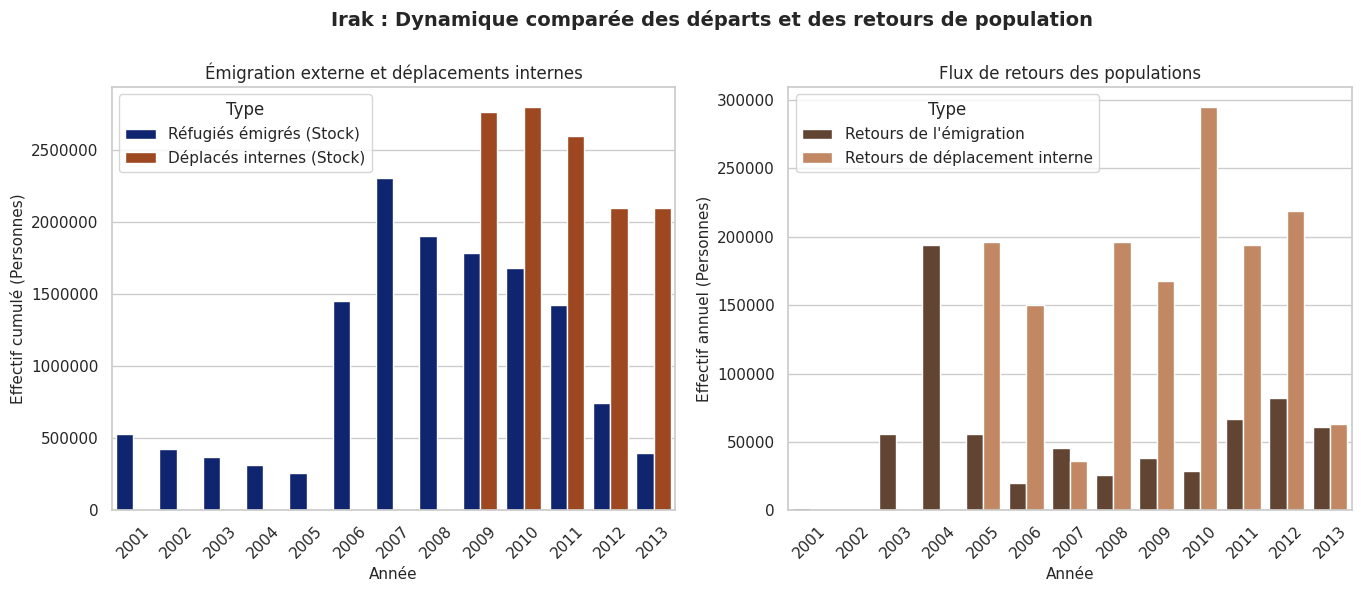

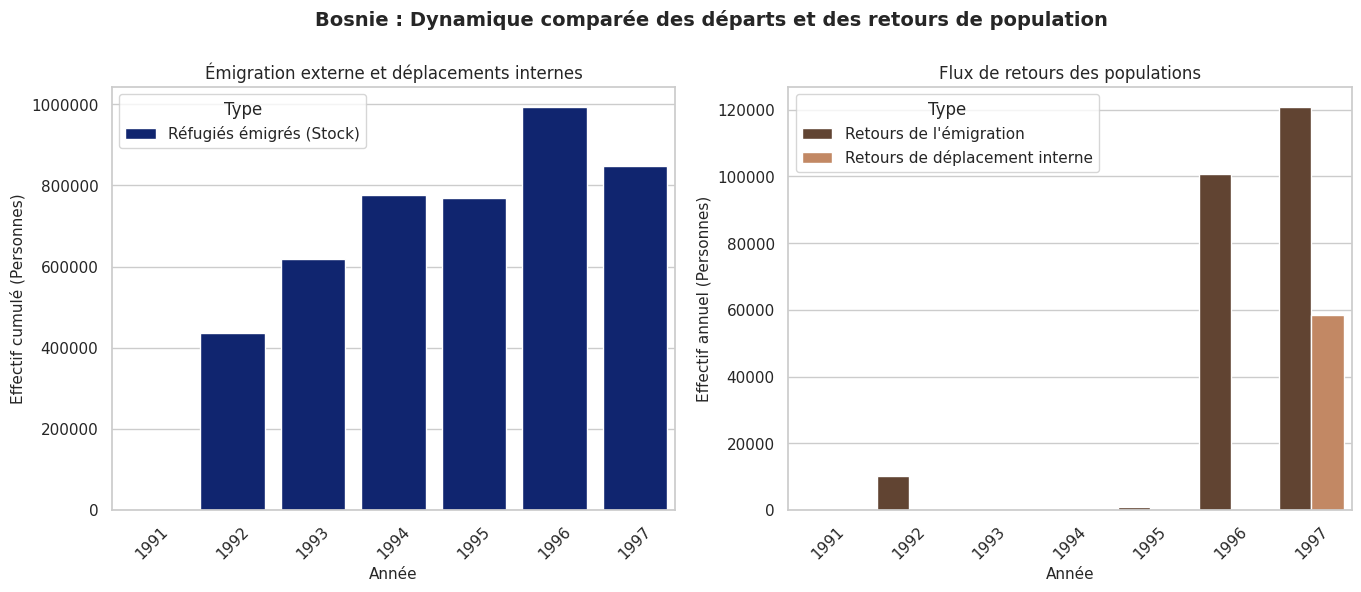

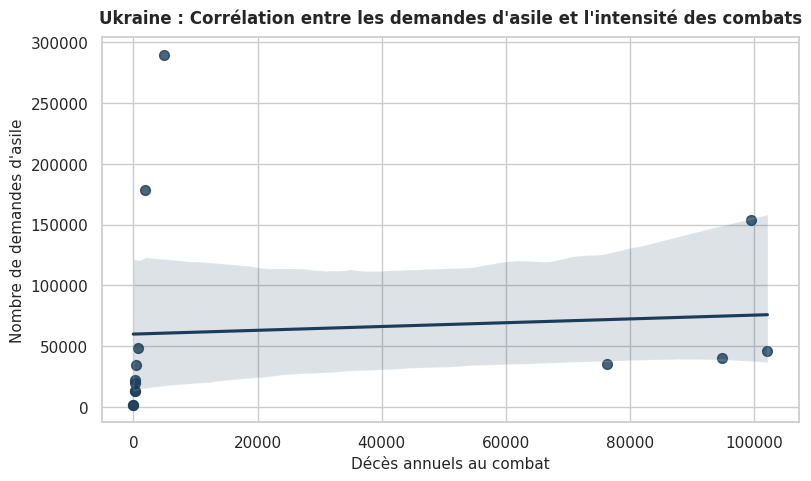

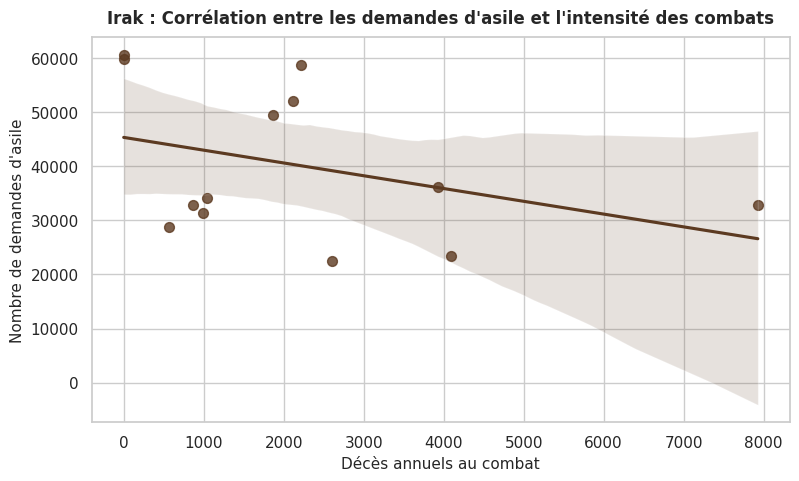

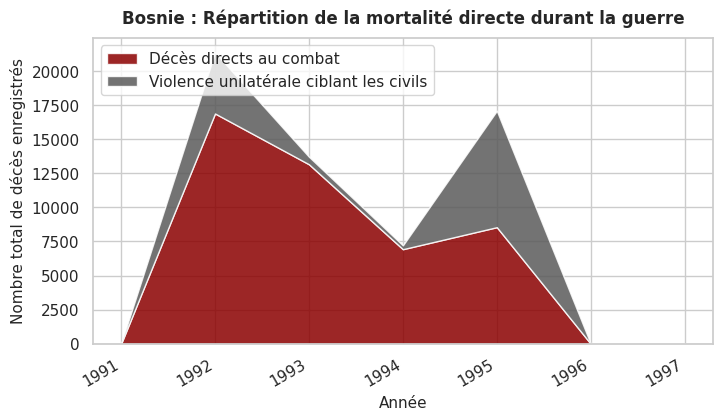

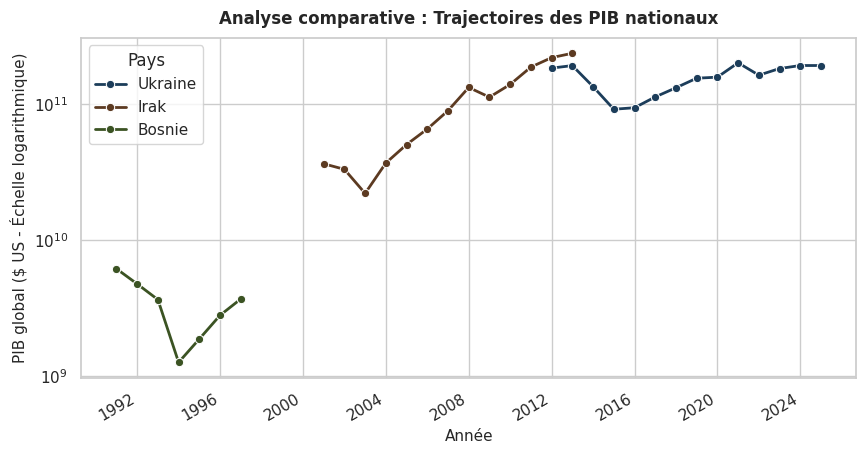

/tmp/ipykernel_6136/2324967183.py:191: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['unhcr_refugees_origin'] > 0], x='Country', y='unhcr_refugees_origin', palette=couleurs_pays)


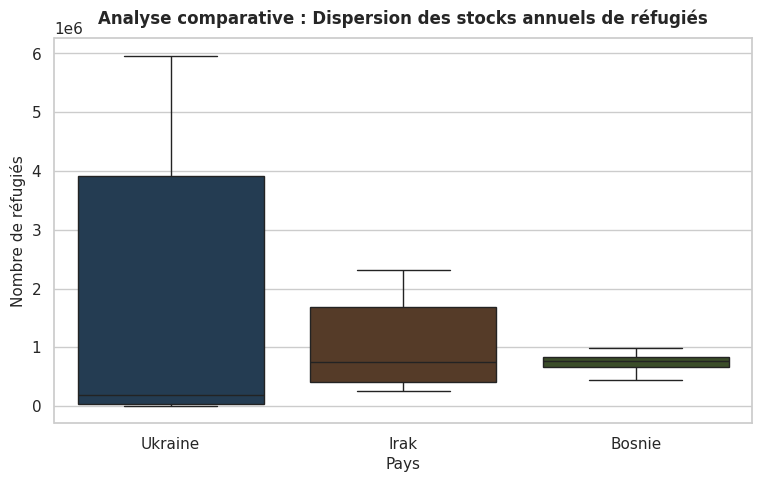

/tmp/ipykernel_6136/2324967183.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_deaths, x='Country', y='conflict_bd_best', palette=couleurs_pays)


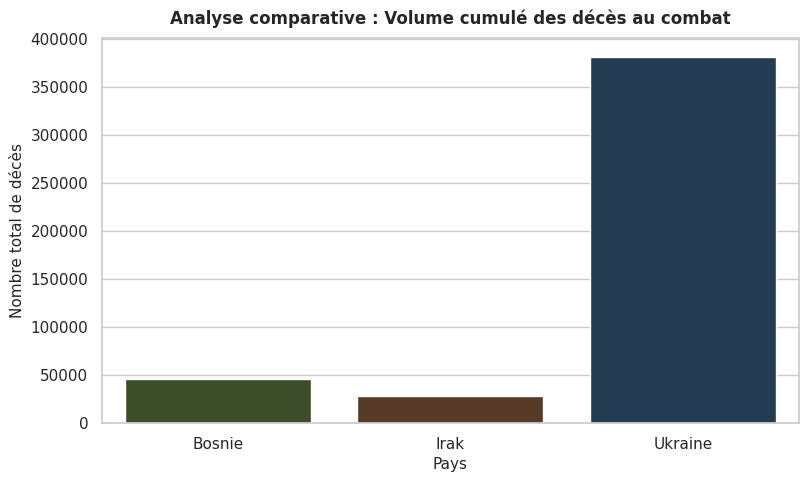

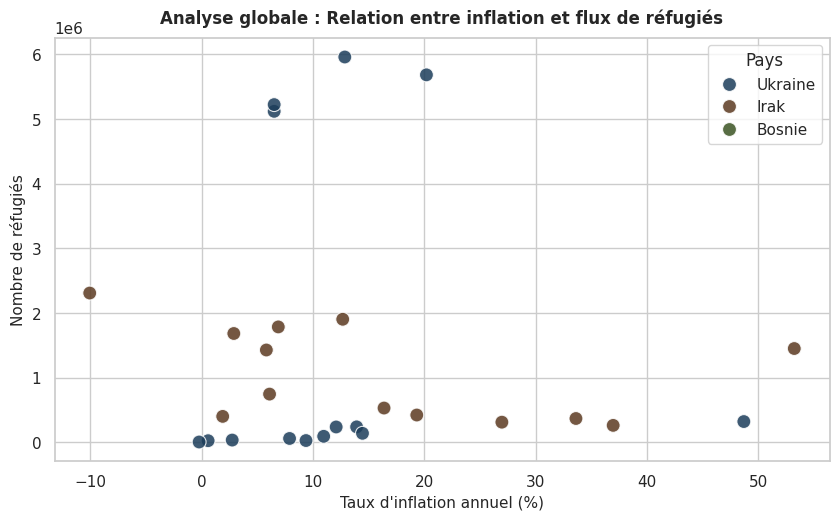

/tmp/ipykernel_6136/2324967183.py:217: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Country', y='Life expectancy at birth, total (years)', estimator=np.mean, errorbar='ci', palette=couleurs_pays)


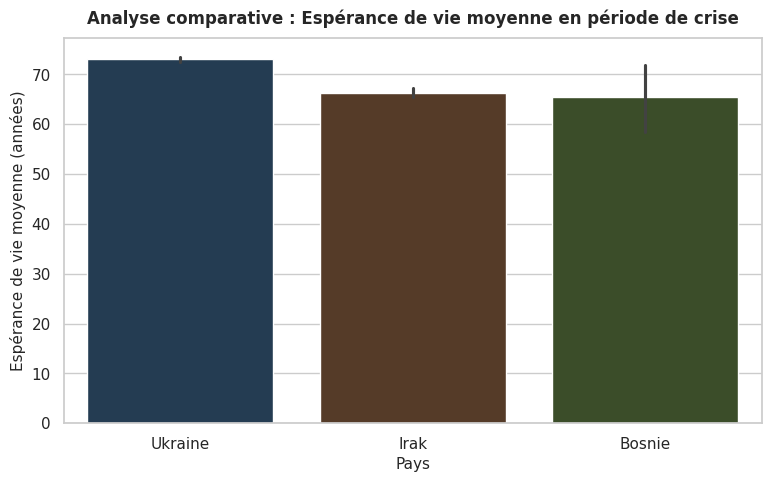

/tmp/ipykernel_6136/2324967183.py:225: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Country', y='onesided_fatality_best', palette=couleurs_pays, inner="points")


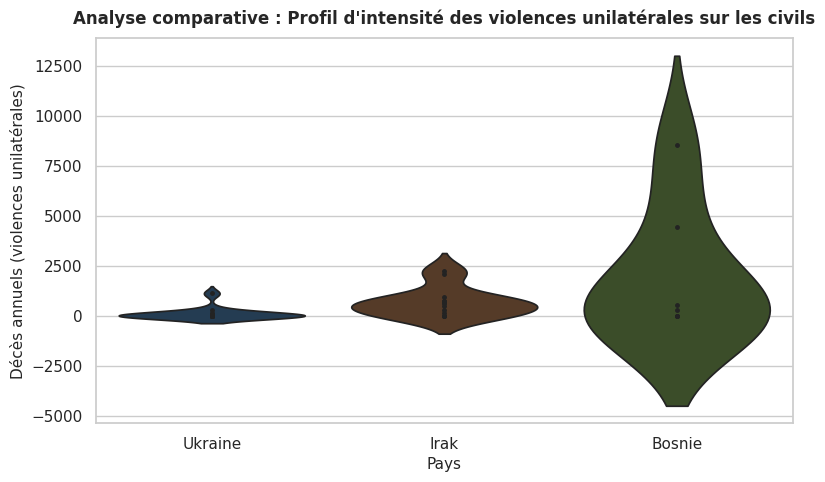

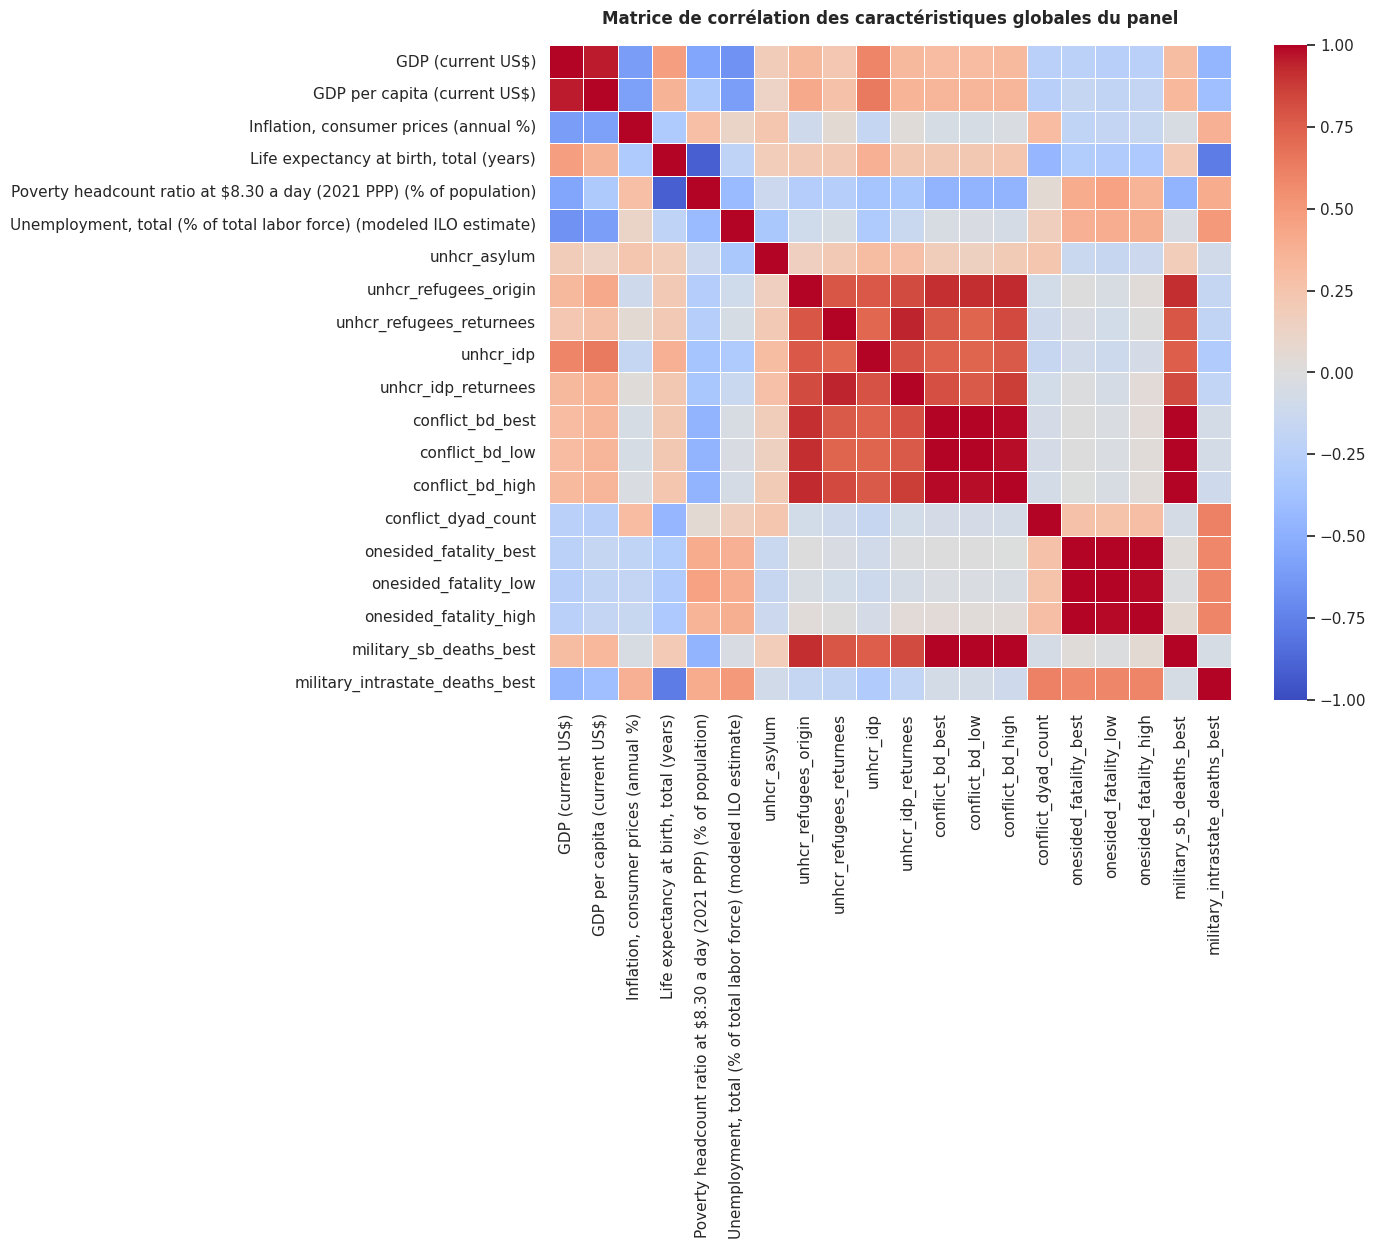

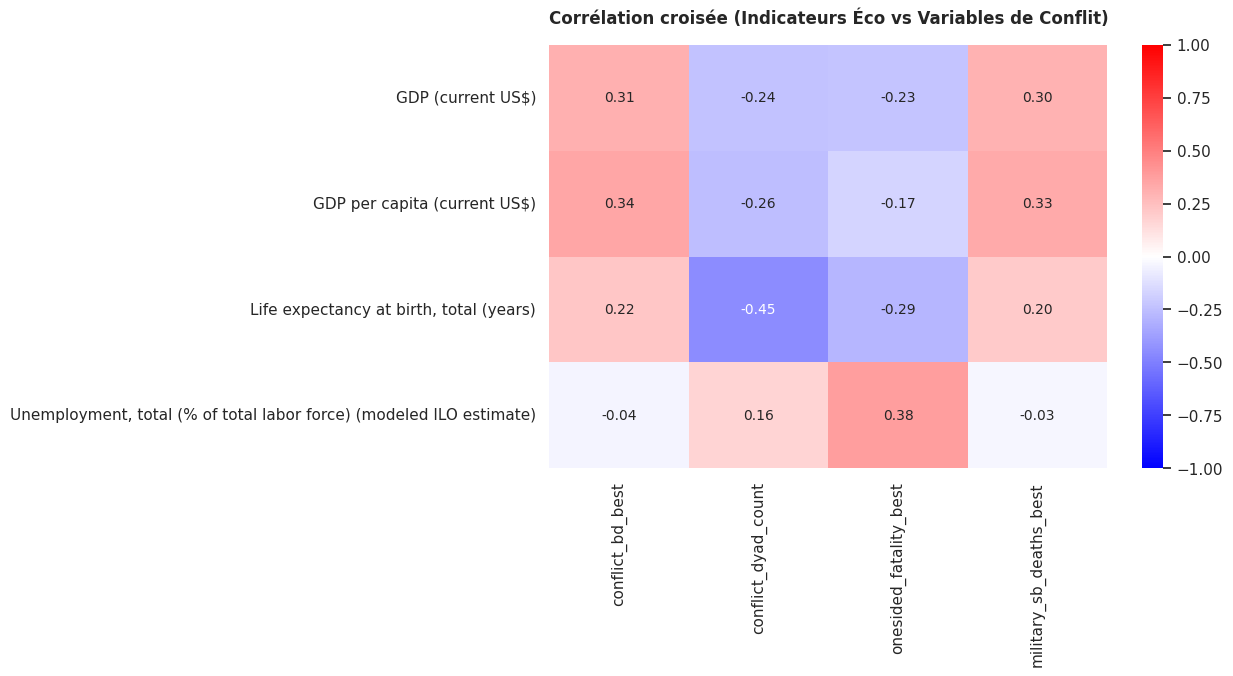

<Figure size 1000x1000 with 0 Axes>

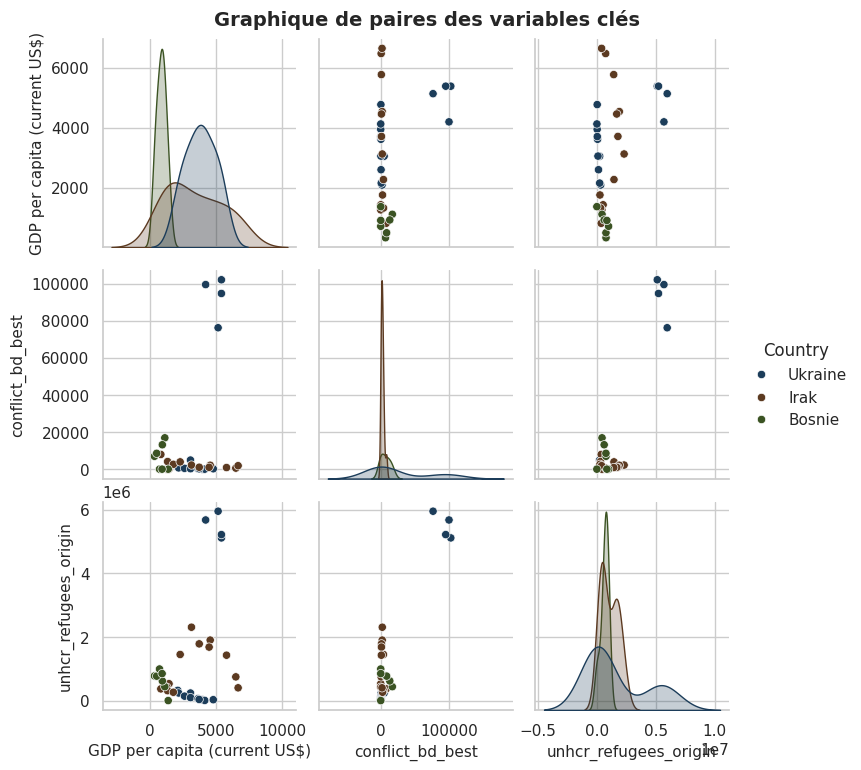

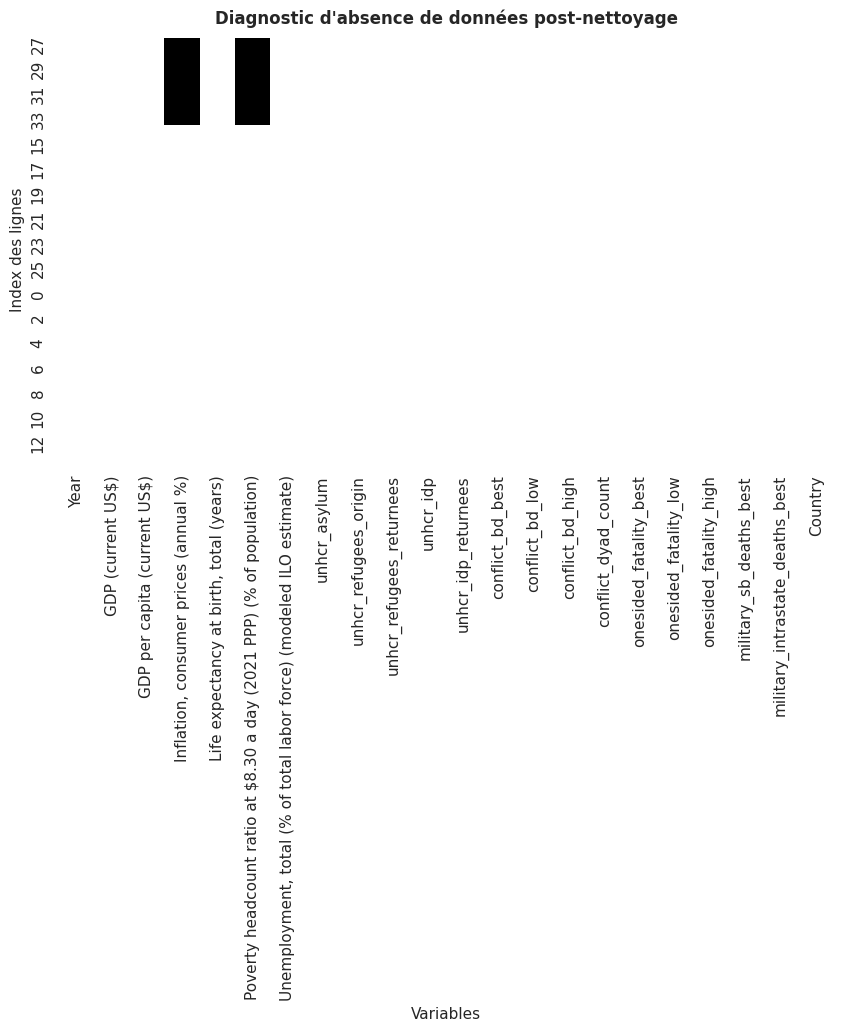

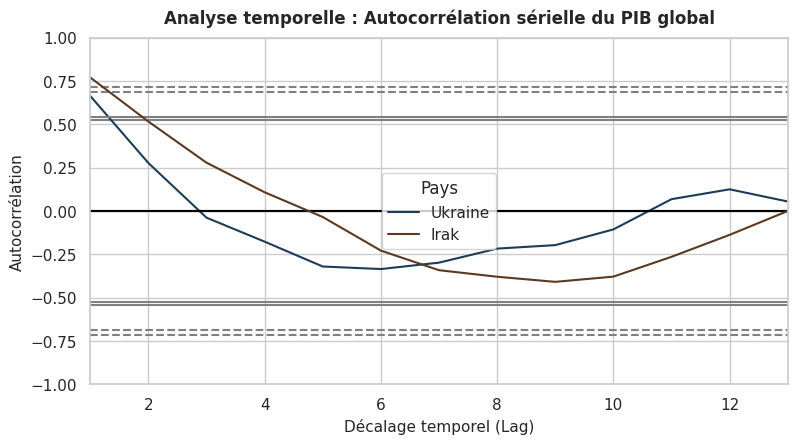

/tmp/ipykernel_6136/2324967183.py:289: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Country', y='unhcr_asylum', palette=couleurs_pays, ax=axs[1,0], estimator=np.sum)


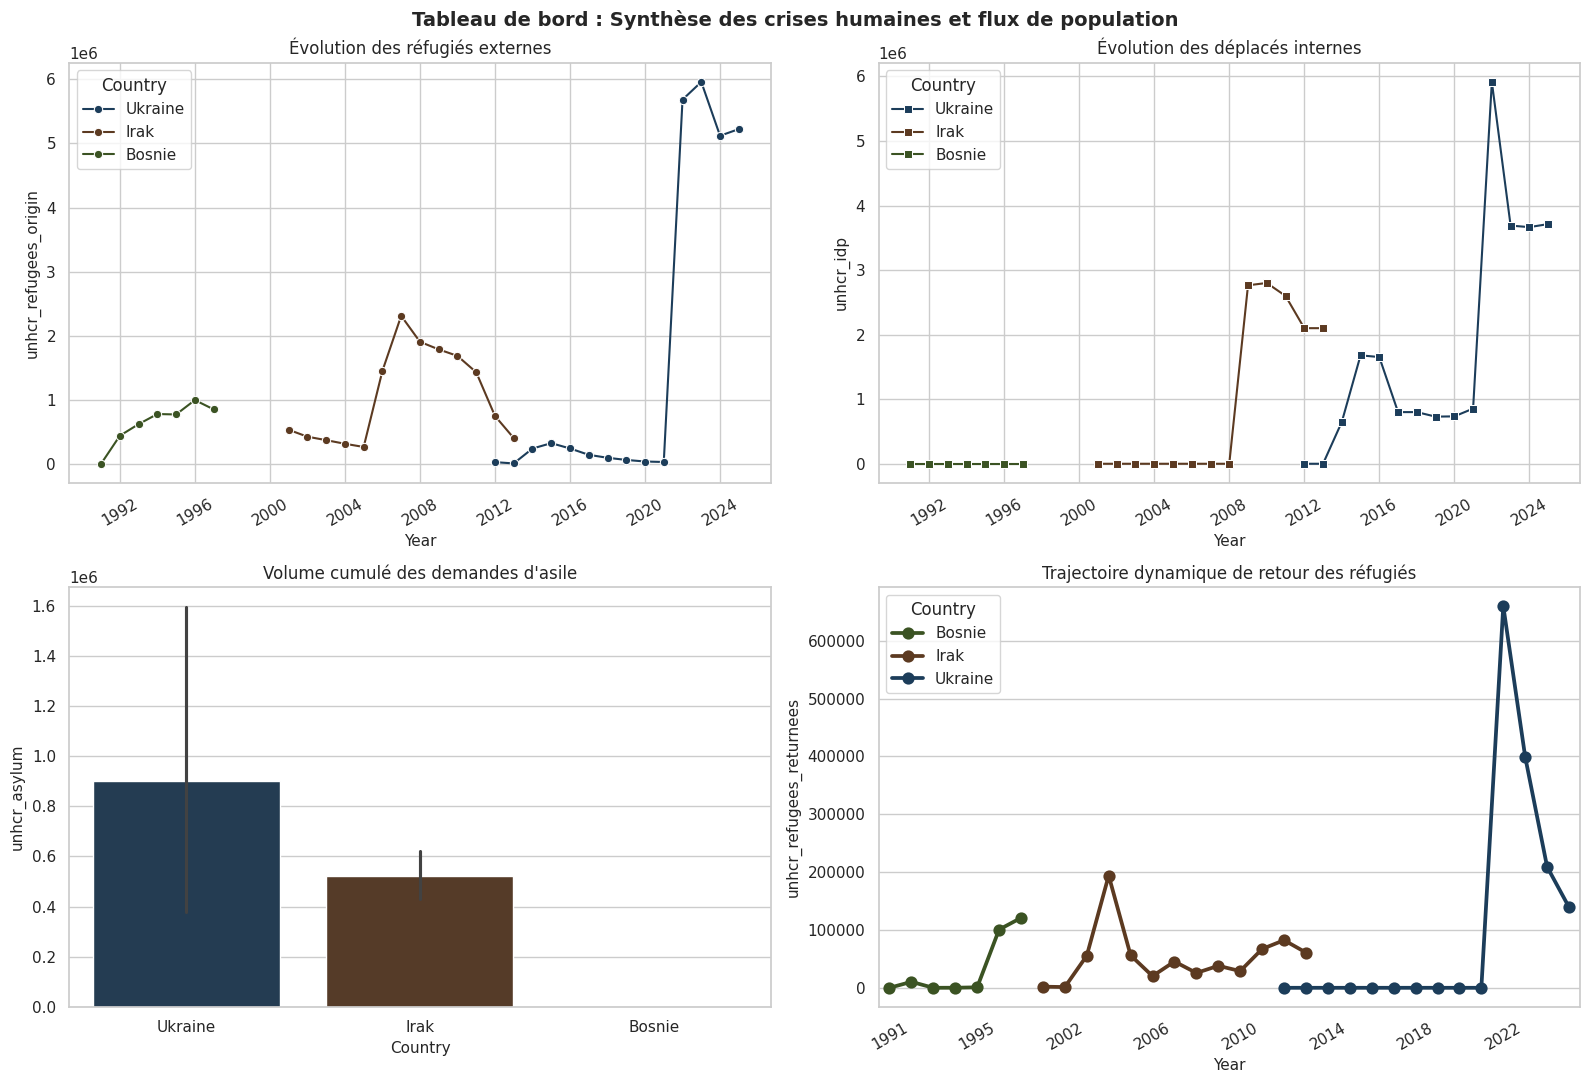

/tmp/ipykernel_6136/2324967183.py:302: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Country', y='GDP (current US$)', palette=couleurs_pays, ax=axs[0,0])
/tmp/ipykernel_6136/2324967183.py:310: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='Country', y='Unemployment, total (% of total labor force) (modeled ILO estimate)', palette=couleurs_pays, ax=axs[1,0], size=6, jitter=0.25)


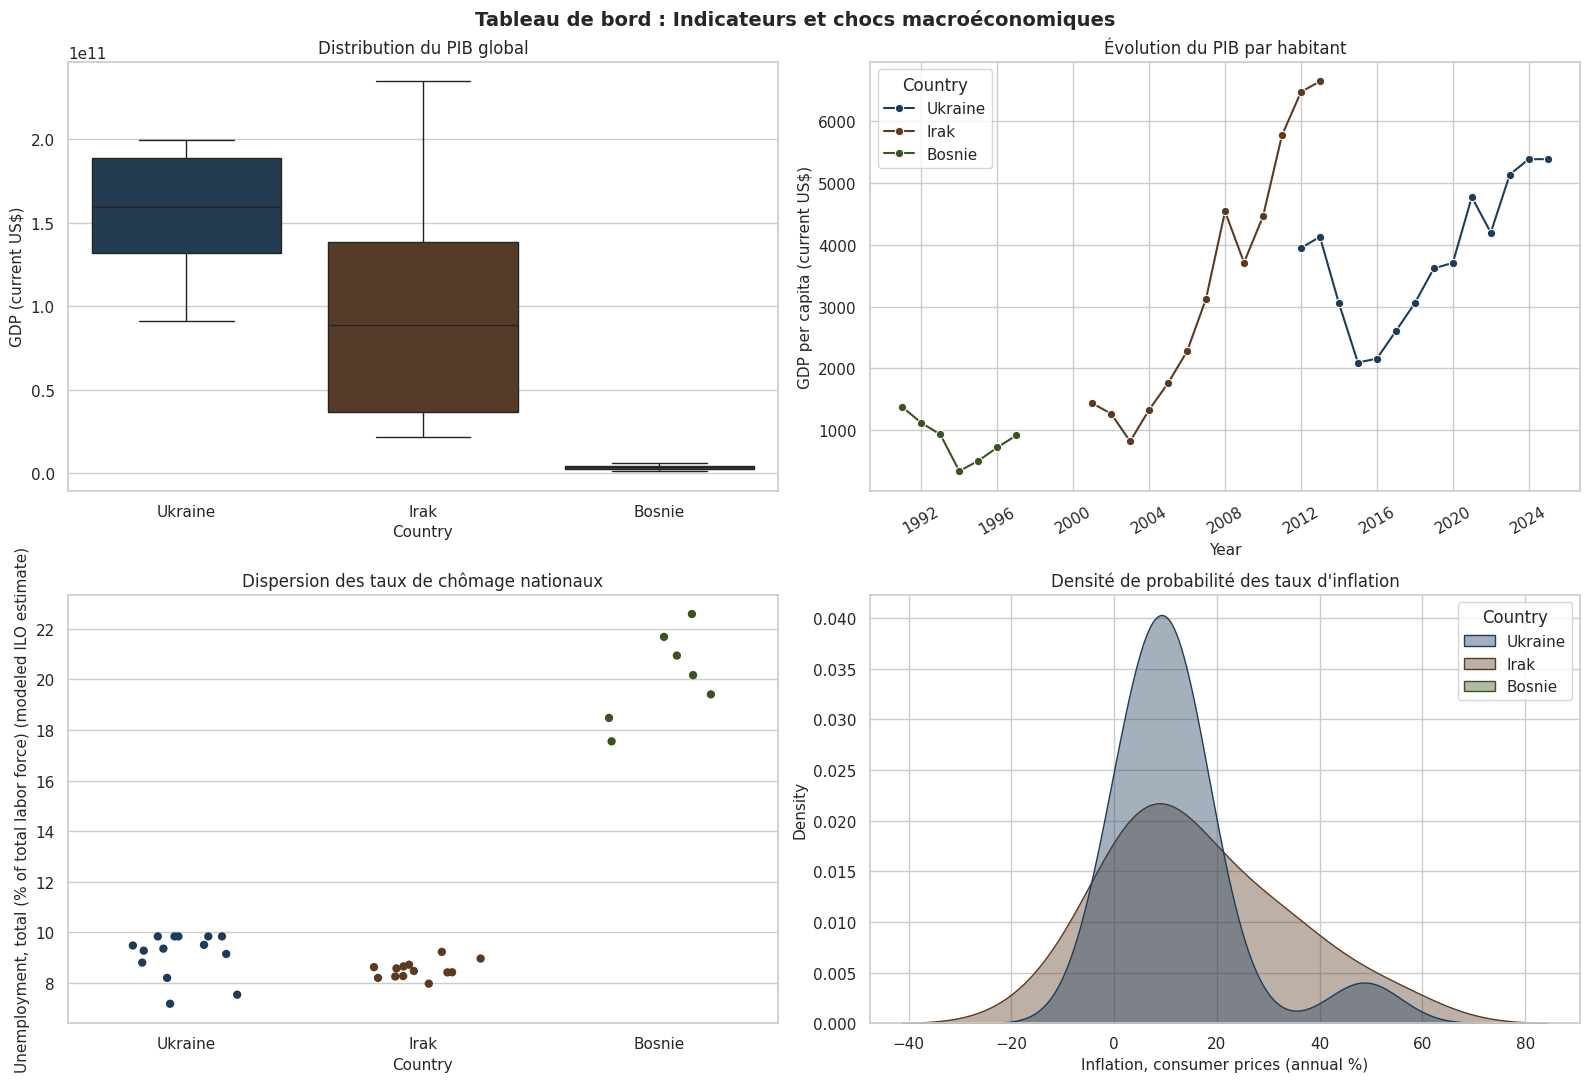

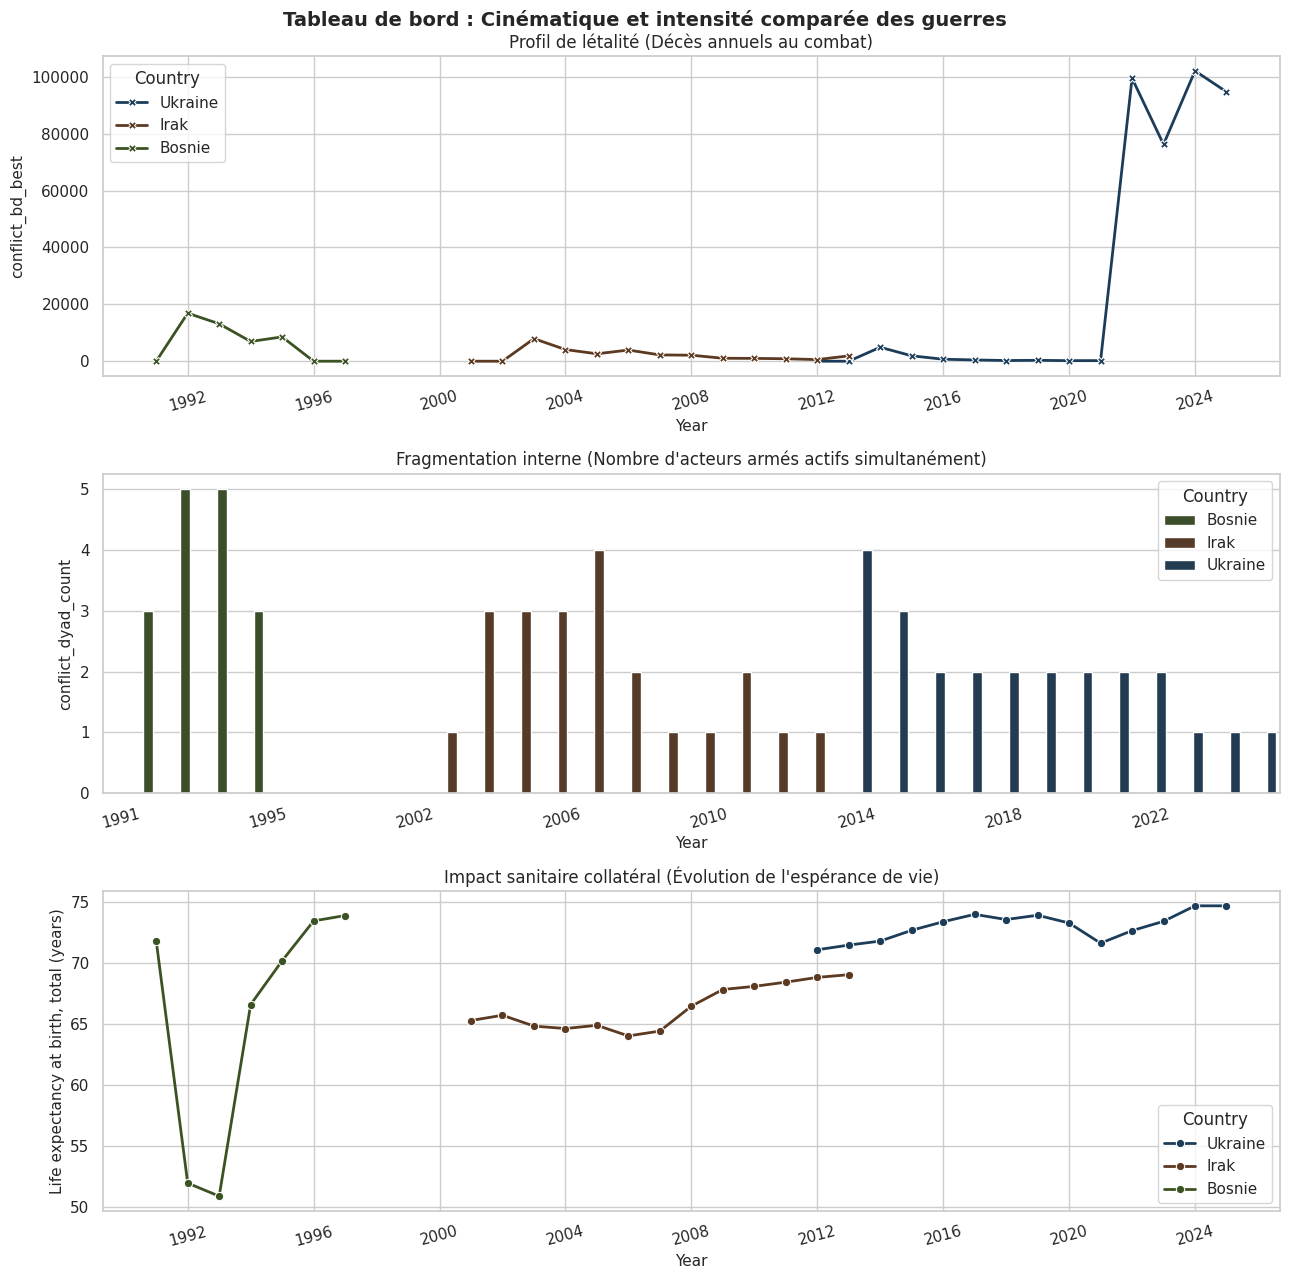

Traitement terminé. Les visuels mis à jour ont été générés.


In [35]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'figure.titlesize': 14
})

df = pd.read_csv("data/cleaned/data_cleaned_panel.csv")

df_ukr = df[df['Country'] == 'Ukraine'].sort_values('Year')
df_irq = df[df['Country'] == 'Irak'].sort_values('Year')
df_bos = df[df['Country'] == 'Bosnie'].sort_values('Year')

os.makedirs("visualisations", exist_ok=True)

couleurs_pays = {
    'Ukraine': '#1c3d5a',
    'Irak': '#5c3a21',
    'Bosnie': '#3b5323'
}

couleur_morts = '#8b0000'
couleur_economie = '#1e4620'
couleur_humanitaire = '#4a2c5c'

fig, ax1 = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_ukr, x='Year', y='unhcr_idp', ax=ax1, color=couleur_humanitaire, marker='o', linewidth=2, label="Déplacés internes (Stock)")
ax1.set_title("Ukraine : Évolution des déplacements internes face à l'intensification des combats", fontweight='bold', pad=10)
ax1.set_xlabel("Année")
ax1.set_ylabel("Nombre de personnes déplacées internes", color=couleur_humanitaire)
ax1.tick_params(axis='y', labelcolor=couleur_humanitaire)
ax1.yaxis.get_major_formatter().set_scientific(False)
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax2 = ax1.twinx()
ax2.bar(df_ukr['Year'], df_ukr['conflict_bd_best'], color=couleur_morts, alpha=0.3, width=0.6, label="Décès au combat")
ax2.set_ylabel("Décès annuels au combat", color=couleur_morts)
ax2.tick_params(axis='y', labelcolor=couleur_morts)
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='upper left')
fig.autofmt_xdate()
plt.savefig("visualisations/ukraine_idp_vs_combat.png", dpi=200, bbox_inches='tight')
plt.show()

fig, ax1 = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_irq, x='Year', y='GDP per capita (current US$)', ax=ax1, color=couleur_economie, marker='s', linewidth=2)
ax1.set_title("Irak : Évolution du PIB par habitant et du chômage", fontweight='bold', pad=10)
ax1.set_xlabel("Année")
ax1.set_ylabel("PIB par habitant ($ US)", color=couleur_economie)
ax1.tick_params(axis='y', labelcolor=couleur_economie)
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax2 = ax1.twinx()
sns.lineplot(data=df_irq, x='Year', y='Unemployment, total (% of total labor force) (modeled ILO estimate)', ax=ax2, color='#424242', marker='^', linewidth=2)
ax2.set_ylabel("Taux de chômage (%)", color='#424242')
ax2.tick_params(axis='y', labelcolor='#424242')
ax2.grid(False)
fig.autofmt_xdate()
plt.savefig("visualisations/iraq_gdp_unemployment.png", dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 5))
sns.lineplot(data=df_bos, x='Year', y='Life expectancy at birth, total (years)', color=couleurs_pays['Bosnie'], marker='o', linewidth=2.5)
plt.title("Bosnie : Évolution de l'espérance de vie au cours du conflit", fontweight='bold', pad=10)
plt.xlabel("Année")
plt.ylabel("Espérance de vie (années)")
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.gcf().autofmt_xdate()
plt.savefig("visualisations/bosnia_life_expectancy.png", dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5.5))
sns.lineplot(data=df_ukr, x='Year', y='Life expectancy at birth, total (years)', color=couleurs_pays['Ukraine'], marker='o', linewidth=2.5, label='Ukraine (2012-2025)')
sns.lineplot(data=df_irq, x='Year', y='Life expectancy at birth, total (years)', color=couleurs_pays['Irak'], marker='s', linewidth=2.5, label='Irak (2001-2013)')
sns.lineplot(data=df_bos, x='Year', y='Life expectancy at birth, total (years)', color=couleurs_pays['Bosnie'], marker='^', linewidth=2.5, label='Bosnie (1991-1997)')
plt.title("Analyse comparative globale : Évolution de l'espérance de vie avant, pendant et après les crises", fontweight='bold', pad=10)
plt.xlabel("Année chronologique respective du conflit")
plt.ylabel("Espérance de vie (années)")
plt.legend(title="Contextes d'étude")
plt.gcf().autofmt_xdate()
plt.savefig("visualisations/comparative_life_expectancy_global.png", dpi=200, bbox_inches='tight')
plt.show()

conflits_migratoires = [
    ('Ukraine', df_ukr, ['unhcr_refugees_origin', 'unhcr_idp'], ['unhcr_refugees_returnees', 'unhcr_idp_returnees']),
    ('Irak', df_irq, ['unhcr_refugees_origin', 'unhcr_idp'], ['unhcr_refugees_returnees', 'unhcr_idp_returnees']),
    ('Bosnie', df_bos, ['unhcr_refugees_origin'], ['unhcr_refugees_returnees', 'unhcr_idp_returnees'])
]

mapping_noms = {
    'unhcr_refugees_origin': 'Réfugiés émigrés (Stock)',
    'unhcr_idp': 'Déplacés internes (Stock)',
    'unhcr_refugees_returnees': 'Retours de l\'émigration',
    'unhcr_idp_returnees': 'Retours de déplacement interne'
}

for nom_pays, sub_df, cols_dep, cols_ret in conflits_migratoires:
    cols_dep_existantes = [c for c in cols_dep if c in sub_df.columns and sub_df[c].sum() > 0]
    cols_ret_existantes = [c for c in cols_ret if c in sub_df.columns and sub_df[c].sum() > 0]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5), sharex=False)

    if cols_dep_existantes:
        df_melt_dep = sub_df.melt(id_vars='Year', value_vars=cols_dep_existantes, var_name='Type', value_name='Total')
        df_melt_dep['Type'] = df_melt_dep['Type'].map(mapping_noms)
        sns.barplot(data=df_melt_dep, x='Year', y='Total', hue='Type', ax=ax1, palette='dark')
        ax1.set_title("Émigration externe et déplacements internes")
        ax1.set_ylabel("Effectif cumulé (Personnes)")
        ax1.set_xlabel("Année")
        ax1.tick_params(axis='x', rotation=45)
        ax1.yaxis.get_major_formatter().set_scientific(False)
    else:
        ax1.text(0.5, 0.5, "Données de déplacement non disponibles", transform=ax1.transAxes, ha='center')

    if cols_ret_existantes:
        df_melt_ret = sub_df.melt(id_vars='Year', value_vars=cols_ret_existantes, var_name='Type', value_name='Total')
        df_melt_ret['Type'] = df_melt_ret['Type'].map(mapping_noms)
        sns.barplot(data=df_melt_ret, x='Year', y='Total', hue='Type', ax=ax2, palette='copper')
        ax2.set_title("Flux de retours des populations")
        ax2.set_ylabel("Effectif annuel (Personnes)")
        ax2.set_xlabel("Année")
        ax2.tick_params(axis='x', rotation=45)
        ax2.yaxis.get_major_formatter().set_scientific(False)
    else:
        ax2.text(0.5, 0.5, "Données de retour non disponibles ou nulles", transform=ax2.transAxes, ha='center')

    plt.suptitle(f"{nom_pays} : Dynamique comparée des départs et des retours de population", fontweight='bold', y=1.02)
    plt.savefig(f"visualisations/{nom_pays.lower()}_duo_flux_migratoires.png", dpi=200, bbox_inches='tight')
    plt.show()

for nom_pays, sub_df in [('Ukraine', df_ukr), ('Irak', df_irq)]:
    plt.figure(figsize=(9, 5))
    sns.regplot(data=sub_df, x='conflict_bd_best', y='unhcr_asylum', color=couleurs_pays[nom_pays], scatter_kws={'s':50})
    plt.title(f"{nom_pays} : Corrélation entre les demandes d'asile et l'intensité des combats", fontweight='bold', pad=10)
    plt.xlabel("Décès annuels au combat")
    plt.ylabel("Nombre de demandes d'asile")
    plt.savefig(f"visualisations/{nom_pays.lower()}_reg_asylum_deaths.png", dpi=200, bbox_inches='tight')
    plt.show()

plt.figure(figsize=(8, 4.5))
plt.stackplot(df_bos['Year'], df_bos['conflict_bd_best'], df_bos['onesided_fatality_best'], labels=['Décès directs au combat', 'Violence unilatérale ciblant les civils'], colors=[couleur_morts, '#5a5a5a'], alpha=0.85)
plt.title("Bosnie : Répartition de la mortalité directe durant la guerre", fontweight='bold', pad=10)
plt.xlabel("Année")
plt.ylabel("Nombre total de décès enregistrés")
plt.legend(loc='upper left')
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.gcf().autofmt_xdate()
plt.savefig("visualisations/bosnia_mortality_structure.png", dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Year', y='GDP (current US$)', hue='Country', palette=couleurs_pays, marker='o', linewidth=2)
plt.yscale('log')
plt.title("Analyse comparative : Trajectoires des PIB nationaux", fontweight='bold', pad=10)
plt.xlabel("Année")
plt.ylabel("PIB global ($ US - Échelle logarithmique)")
plt.legend(title="Pays")
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.gcf().autofmt_xdate()
plt.savefig("visualisations/comparative_gdp_log.png", dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 5))
sns.boxplot(data=df[df['unhcr_refugees_origin'] > 0], x='Country', y='unhcr_refugees_origin', palette=couleurs_pays)
plt.title("Analyse comparative : Dispersion des stocks annuels de réfugiés", fontweight='bold', pad=10)
plt.xlabel("Pays")
plt.ylabel("Nombre de réfugiés")
plt.savefig("visualisations/boxplot_refugees.png", dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 5))
df_deaths = df.groupby('Country')['conflict_bd_best'].sum().reset_index()
sns.barplot(data=df_deaths, x='Country', y='conflict_bd_best', palette=couleurs_pays)
plt.title("Analyse comparative : Volume cumulé des décès au combat", fontweight='bold', pad=10)
plt.xlabel("Pays")
plt.ylabel("Nombre total de décès")
plt.savefig("visualisations/total_conflict_deaths.png", dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5.5))
sns.scatterplot(data=df, x='Inflation, consumer prices (annual %)', y='unhcr_refugees_origin', hue='Country', palette=couleurs_pays, s=100, alpha=0.85)
plt.title("Analyse globale : Relation entre inflation et flux de réfugiés", fontweight='bold', pad=10)
plt.xlabel("Taux d'inflation annuel (%)")
plt.ylabel("Nombre de réfugiés")
plt.legend(title="Pays")
plt.savefig("visualisations/scatter_inflation_refugees.png", dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='Country', y='Life expectancy at birth, total (years)', estimator=np.mean, errorbar='ci', palette=couleurs_pays)
plt.title("Analyse comparative : Espérance de vie moyenne en période de crise", fontweight='bold', pad=10)
plt.xlabel("Pays")
plt.ylabel("Espérance de vie moyenne (années)")
plt.savefig("visualisations/mean_life_expectancy.png", dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x='Country', y='onesided_fatality_best', palette=couleurs_pays, inner="points")
plt.title("Analyse comparative : Profil d'intensité des violences unilatérales sur les civils", fontweight='bold', pad=10)
plt.xlabel("Pays")
plt.ylabel("Décès annuels (violences unilatérales)")
plt.savefig("visualisations/violin_onesided.png", dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(11, 8.5))
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'Year']
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matrice de corrélation des caractéristiques globales du panel", fontweight='bold', pad=15)
plt.savefig("visualisations/global_correlation_heatmap.png", dpi=200, bbox_inches='tight')
plt.show()

eco_vars = ['GDP (current US$)', 'GDP per capita (current US$)', 'Life expectancy at birth, total (years)', 'Unemployment, total (% of total labor force) (modeled ILO estimate)']
conflict_vars = ['conflict_bd_best', 'conflict_dyad_count', 'onesided_fatality_best', 'military_sb_deaths_best']
plt.figure(figsize=(9, 5.5))
cross_corr = df[eco_vars + conflict_vars].corr().loc[eco_vars, conflict_vars]
sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap='bwr', vmin=-1, vmax=1)
plt.title("Corrélation croisée (Indicateurs Éco vs Variables de Conflit)", fontweight='bold', pad=15)
plt.savefig("visualisations/cross_correlation.png", dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 10))
selected_features = ['GDP per capita (current US$)', 'conflict_bd_best', 'unhcr_refugees_origin', 'Country']
g = sns.pairplot(df[selected_features], hue='Country', palette=couleurs_pays, diag_kind='kde', height=2.5)
g.fig.suptitle("Graphique de paires des variables clés", y=1.02, fontweight='bold')
plt.savefig("visualisations/pairplot_ml.png", dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5.5))
sns.heatmap(df.sort_values(['Country', 'Year']).isna(), cbar=False, cmap='binary')
plt.title("Diagnostic d'absence de données post-nettoyage", fontweight='bold', pad=10)
plt.xlabel("Variables")
plt.ylabel("Index des lignes")
plt.savefig("visualisations/missing_data_map.png", dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 4.5))
pd.plotting.autocorrelation_plot(df_ukr['GDP (current US$)'], color=couleurs_pays['Ukraine'], label='Ukraine')
pd.plotting.autocorrelation_plot(df_irq['GDP (current US$)'], color=couleurs_pays['Irak'], label='Irak')
plt.title("Analyse temporelle : Autocorrélation sérielle du PIB global", fontweight='bold', pad=10)
plt.xlabel("Décalage temporel (Lag)")
plt.ylabel("Autocorrélation")
plt.legend(title="Pays")
plt.savefig("visualisations/autocorrelation_gdp.png", dpi=200, bbox_inches='tight')
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(16, 11))
sns.lineplot(data=df, x='Year', y='unhcr_refugees_origin', hue='Country', palette=couleurs_pays, ax=axs[0,0], marker='o')
axs[0,0].set_title("Évolution des réfugiés externes")
axs[0,0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axs[0,0].tick_params(axis='x', rotation=30)

sns.lineplot(data=df, x='Year', y='unhcr_idp', hue='Country', palette=couleurs_pays, ax=axs[0,1], marker='s')
axs[0,1].set_title("Évolution des déplacés internes")
axs[0,1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axs[0,1].tick_params(axis='x', rotation=30)

sns.barplot(data=df, x='Country', y='unhcr_asylum', palette=couleurs_pays, ax=axs[1,0], estimator=np.sum)
axs[1,0].set_title("Volume cumulé des demandes d'asile")

sns.pointplot(data=df, x='Year', y='unhcr_refugees_returnees', hue='Country', palette=couleurs_pays, ax=axs[1,1])
axs[1,1].set_title("Trajectoire dynamique de retour des réfugiés")
axs[1,1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axs[1,1].tick_params(axis='x', rotation=30)
plt.suptitle("Tableau de bord : Synthèse des crises humaines et flux de population", fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig("visualisations/dashboard_humanitaire.png", dpi=200)
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(16, 11))
sns.boxplot(data=df, x='Country', y='GDP (current US$)', palette=couleurs_pays, ax=axs[0,0])
axs[0,0].set_title("Distribution du PIB global")

sns.lineplot(data=df, x='Year', y='GDP per capita (current US$)', hue='Country', palette=couleurs_pays, ax=axs[0,1], marker='o')
axs[0,1].set_title("Évolution du PIB par habitant")
axs[0,1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axs[0,1].tick_params(axis='x', rotation=30)

sns.stripplot(data=df, x='Country', y='Unemployment, total (% of total labor force) (modeled ILO estimate)', palette=couleurs_pays, ax=axs[1,0], size=6, jitter=0.25)
axs[1,0].set_title("Dispersion des taux de chômage nationaux")

sns.kdeplot(data=df, x='Inflation, consumer prices (annual %)', hue='Country', palette=couleurs_pays, ax=axs[1,1], fill=True, common_norm=False, alpha=0.4)
axs[1,1].set_title("Densité de probabilité des taux d'inflation")
plt.suptitle("Tableau de bord : Indicateurs et chocs macroéconomiques", fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig("visualisations/dashboard_economique.png", dpi=200)
plt.show()

fig, axs = plt.subplots(3, 1, figsize=(13, 13), sharex=False)
sns.lineplot(data=df, x='Year', y='conflict_bd_best', hue='Country', palette=couleurs_pays, ax=axs[0], marker='X', linewidth=2)
axs[0].set_title("Profil de létalité (Décès annuels au combat)")
axs[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axs[0].tick_params(axis='x', rotation=15)

sns.barplot(data=df, x='Year', y='conflict_dyad_count', hue='Country', palette=couleurs_pays, ax=axs[1])
axs[1].set_title("Fragmentation interne (Nombre d'acteurs armés actifs simultanément)")
axs[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axs[1].tick_params(axis='x', rotation=15)

sns.lineplot(data=df, x='Year', y='Life expectancy at birth, total (years)', hue='Country', palette=couleurs_pays, ax=axs[2], marker='o', linewidth=2)
axs[2].set_title("Impact sanitaire collatéral (Évolution de l'espérance de vie)")
axs[2].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axs[2].tick_params(axis='x', rotation=15)
plt.suptitle("Tableau de bord : Cinématique et intensité comparée des guerres", fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig("visualisations/dashboard_conflit_cinematique.png", dpi=200)
plt.show()

print("Traitement terminé. Les visuels mis à jour ont été générés.")

=== Évaluation de la Classification ===
Exactitude (Accuracy) : 0.7500 (75.00 %)

=== Rapport de Classification ===
                          precision    recall  f1-score   support

Stabilité/Croissance (0)       0.83      0.83      0.83         6
     Choc Économique (1)       0.50      0.50      0.50         2

                accuracy                           0.75         8
               macro avg       0.67      0.67      0.67         8
            weighted avg       0.75      0.75      0.75         8

=== Importance des variables explicatives ===
- conflict_bd_best_lag1 : 0.2413
- conflict_bd_best : 0.2327
- conflict_dyad_count_lag1 : 0.1482
- conflict_dyad_count : 0.1201
- onesided_fatality_best : 0.0930
- onesided_fatality_best_lag1 : 0.0498
- Country_Irak : 0.0490
- Country_Ukraine : 0.0401
- Country_Bosnie : 0.0258


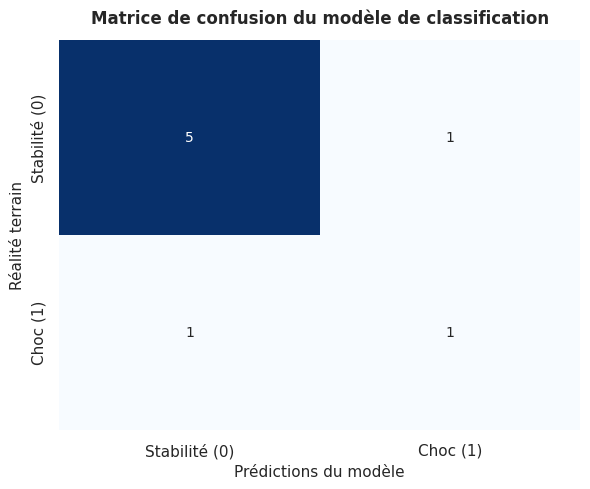

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

df = pd.read_csv("data/cleaned/data_cleaned_panel.csv")

df_list = []
for country in df['Country'].unique():
    sub_df = df[df['Country'] == country].sort_values('Year').copy()

    sub_df['gdp_capita_pct_change'] = sub_df['GDP per capita (current US$)'].pct_change()

    sub_df['Choc_Economique'] = (sub_df['gdp_capita_pct_change'] < 0).astype(int)

    for col in ['conflict_bd_best', 'conflict_dyad_count', 'onesided_fatality_best']:
        sub_df[f'{col}_lag1'] = sub_df[col].shift(1)

    df_list.append(sub_df)

df_ml = pd.concat(df_list).dropna(subset=['conflict_bd_best_lag1', 'Choc_Economique'])

df_ml = pd.get_dummies(df_ml, columns=['Country'], drop_first=False)
country_cols = [c for c in df_ml.columns if 'Country_' in c]

features = [
    'conflict_bd_best', 'conflict_dyad_count', 'onesided_fatality_best',
    'conflict_bd_best_lag1', 'conflict_dyad_count_lag1', 'onesided_fatality_best_lag1'
] + country_cols
target = 'Choc_Economique'

X = df_ml[features]
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

predictions = rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"=== Évaluation de la Classification ===")
print(f"Exactitude (Accuracy) : {accuracy:.4f} ({accuracy * 100:.2f} %)\n")

print("=== Rapport de Classification ===")
print(classification_report(y_test, predictions, target_names=["Stabilité/Croissance (0)", "Choc Économique (1)"]))

print("=== Importance des variables explicatives ===")
importances = dict(zip(features, rf_classifier.feature_importances_))
for feat, imp in sorted(importances.items(), key=lambda x: x[1], reverse=True):
    print(f"- {feat} : {imp:.4f}")


plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Stabilité (0)", "Choc (1)"],
            yticklabels=["Stabilité (0)", "Choc (1)"])

plt.title("Matrice de confusion du modèle de classification", fontweight='bold', pad=12)
plt.xlabel("Prédictions du modèle")
plt.ylabel("Réalité terrain")
plt.tight_layout()

plt.savefig("visualisations/matrice_confusion_rf.png", dpi=200, bbox_inches='tight')
plt.show()